In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.utils import resample

# 화이트 와인 데이터 로드
white_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
white_wine = pd.read_csv(white_wine_url, sep=';')

# 레드 와인 데이터 로드
red_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
red_wine = pd.read_csv(red_wine_url, sep=';')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

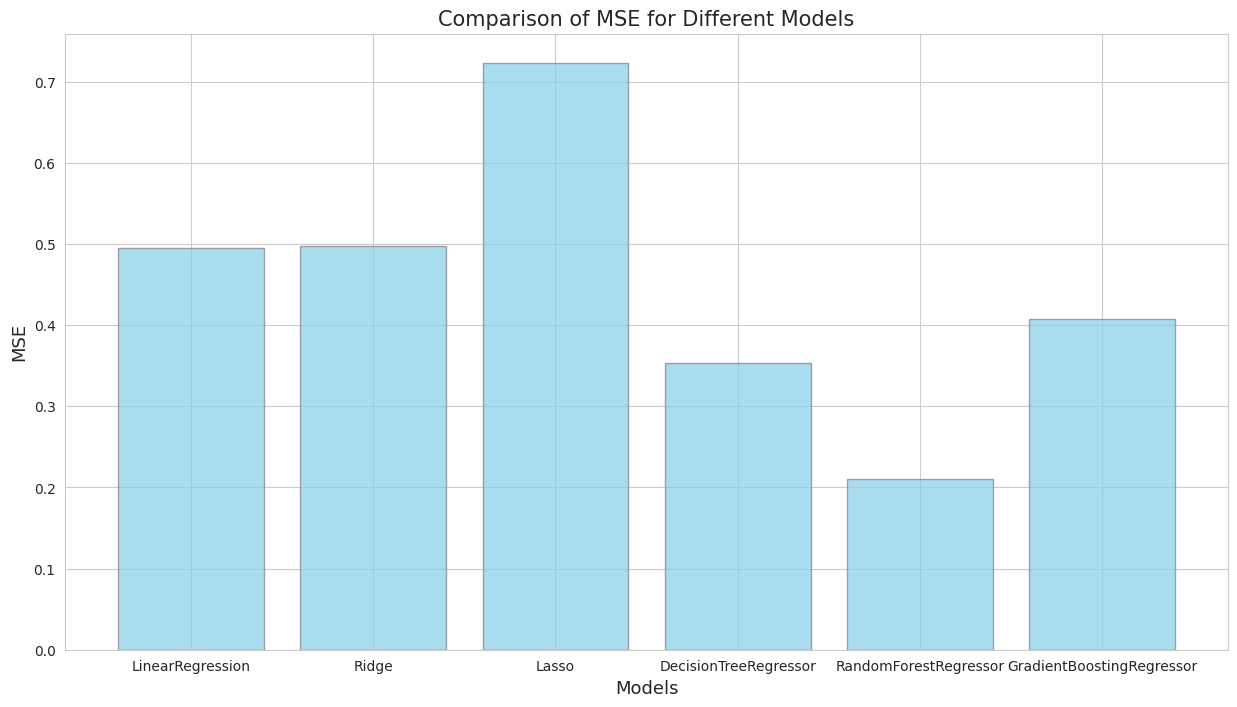

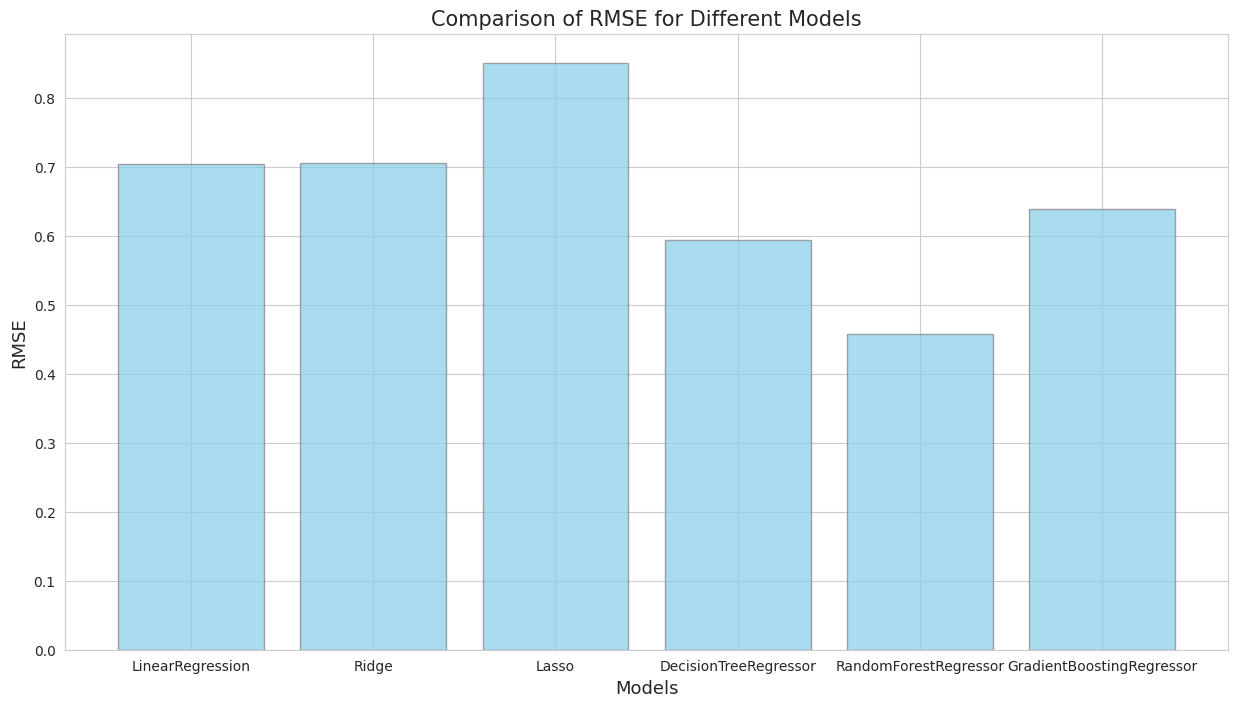

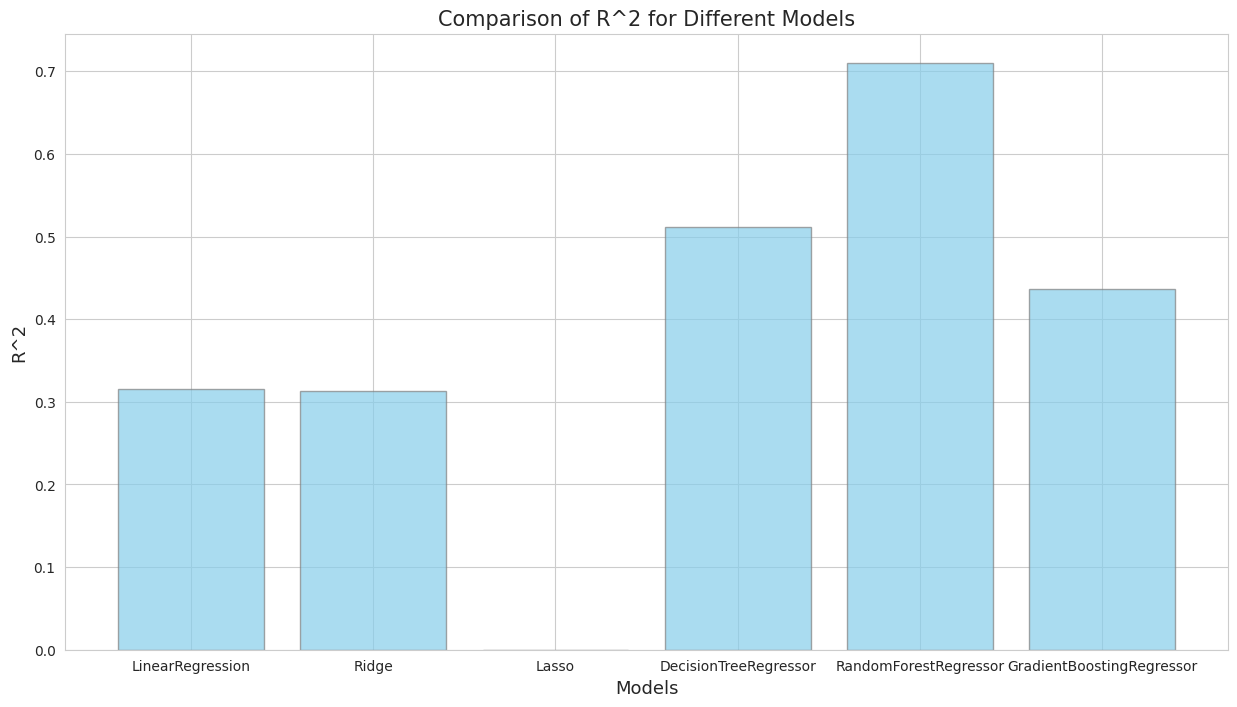

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 스타일 설정
sns.set_style("whitegrid")

# 모델과 그에 따른 성능 지표를 딕셔너리 형태로 저장
results = {
    'LinearRegression': {'MSE': 0.495, 'RMSE': 0.704, 'R^2': 0.316},
    'Ridge': {'MSE': 0.497, 'RMSE': 0.705, 'R^2': 0.313},
    'Lasso': {'MSE': 0.723, 'RMSE': 0.850, 'R^2': -0.000},
    'DecisionTreeRegressor': {'MSE': 0.353, 'RMSE': 0.594, 'R^2': 0.512},
    'RandomForestRegressor': {'MSE': 0.210, 'RMSE': 0.458, 'R^2': 0.710},
    'GradientBoostingRegressor': {'MSE': 0.407, 'RMSE': 0.638, 'R^2': 0.437}
}

# 각 성능 지표에 대한 그래프를 그립니다.
for metric in ['MSE', 'RMSE', 'R^2']:
    plt.figure(figsize=(15, 8))

    # 바 색상 지정, 그림자 추가
    plt.bar(results.keys(), [value[metric] for value in results.values()], color='skyblue', edgecolor='gray', alpha=0.7)

    # 제목 및 레이블 폰트 크기 조절
    plt.title(f'Comparison of {metric} for Different Models', fontsize=15)
    plt.xlabel('Models', fontsize=13)
    plt.ylabel(metric, fontsize=13)

from google.colab import files
plt.savefig('statistic.png')
files.download('statistic.png')

In [ ]:
# 데이터 구조 확인
#white_wine.info()
#red_wine.info()

# # 첫 몇 줄 보기
# white_wine.head()
# print(red_wine.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
화이트 데이터셋 새로운 특성 추가
total sulfur dioxide와 density의 상호작용
total sulfur dioxide, density, residual sugar의 조합
free sulfur dioxide와 total sulfur dioxide의 상호작용
total sulfur dioxide와 density의 조합
pH와 fixed acidity의 조합
residual sugar와 total sulfur dioxide의 조합
density와 alcohol의 조합